# EDA #

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Daten laden
df = pd.read_csv('../data/raw/ga4_merch_store_raw.csv')

print(df.shape)
print(df.dtypes)
df.head()

(92475, 12)
user_pseudo_id       float64
event_date               str
traffic_medium           str
traffic_source           str
device_category          str
session_count          int64
items_viewed           int64
add_to_cart_count      int64
checkout_started       int64
purchases              int64
converted              int64
item_category        float64
dtype: object


,user_pseudo_id,event_date,traffic_medium,traffic_source,device_category,session_count,items_viewed,add_to_cart_count,checkout_started,purchases,converted,item_category
0,1005694.58,2020-11-01,organic,google,desktop,1,0,0,0,0,0,NaN
1,1013442.50,2020-11-01,(none),(direct),mobile,1,1,0,0,0,0,NaN
2,1019516.66,2020-11-01,referral,<Other>,desktop,1,0,0,0,0,0,NaN
3,1019516.66,2020-11-01,(none),(direct),desktop,1,0,0,0,0,0,NaN
4,1055429.25,2020-11-01,<Other>,<Other>,desktop,1,0,0,0,0,0,NaN


In [12]:
# Nulls und Duplikate
print("Nulls:")
print(df.isnull().sum())
print(f"\nDuplikate: {df.duplicated().sum()}")
print(f"\nConversion Rate: {df['converted'].mean():.2%}")

Nulls:
user_pseudo_id       0
event_date           0
traffic_medium       0
traffic_source       0
device_category      0
session_count        0
items_viewed         0
add_to_cart_count    0
checkout_started     0
purchases            0
converted            0
dtype: int64

Duplikate: 0

Conversion Rate: 1.30%


In [14]:
# Bereinigung
df = df.drop(columns=['item_category'])
df['user_pseudo_id'] = df['user_pseudo_id'].astype(str)
df['event_date'] = pd.to_datetime(df['event_date'])

# "data deleted" Zeilen entfernen
df = df[df['traffic_medium'] != '(data deleted)']

print(df.shape)
df.dtypes

(85598, 11)


user_pseudo_id                  str
event_date           datetime64[us]
traffic_medium                  str
traffic_source                  str
device_category                 str
session_count                 int64
items_viewed                  int64
add_to_cart_count             int64
checkout_started              int64
purchases                     int64
converted                     int64
dtype: object

In [15]:
# Funnel Analyse
funnel = {
    'Items Viewed': df['items_viewed'].sum(),
    'Add to Cart': df['add_to_cart_count'].sum(),
    'Checkout Started': df['checkout_started'].sum(),
    'Purchases': df['purchases'].sum()
}

for step, count in funnel.items():
    print(f"{step}: {count:,}")

# Device Breakdown
print("\nDevice:")
print(df['device_category'].value_counts(normalize=True).mul(100).round(1))

# Traffic Medium
print("\nTraffic Medium:")
print(df['traffic_medium'].value_counts(normalize=True).mul(100).round(1))

Items Viewed: 119,690
Add to Cart: 3,005
Checkout Started: 6,959
Purchases: 1,469

Device:
device_category
desktop   58.00
mobile    39.80
tablet     2.20
Name: proportion, dtype: float64

Traffic Medium:
traffic_medium
organic    35.70
(none)     24.80
referral   19.90
<Other>    15.10
cpc         4.50
Name: proportion, dtype: float64


In [17]:
# Conversion Rate nach Device
print("Conversion Rate nach Device:")
print(df.groupby('device_category')['converted'].mean().mul(100).round(2))

# Conversion Rate nach Traffic Medium
print("\nConversion Rate nach Traffic Medium:")
print(df.groupby('traffic_medium')['converted'].mean().mul(100).round(2).sort_values(ascending=False))

Conversion Rate nach Device:
device_category
desktop   1.26
mobile    1.37
tablet    1.06
Name: converted, dtype: float64

Conversion Rate nach Traffic Medium:
traffic_medium
referral   1.72
(none)     1.38
<Other>    1.12
organic    1.12
cpc        1.04
Name: converted, dtype: float64


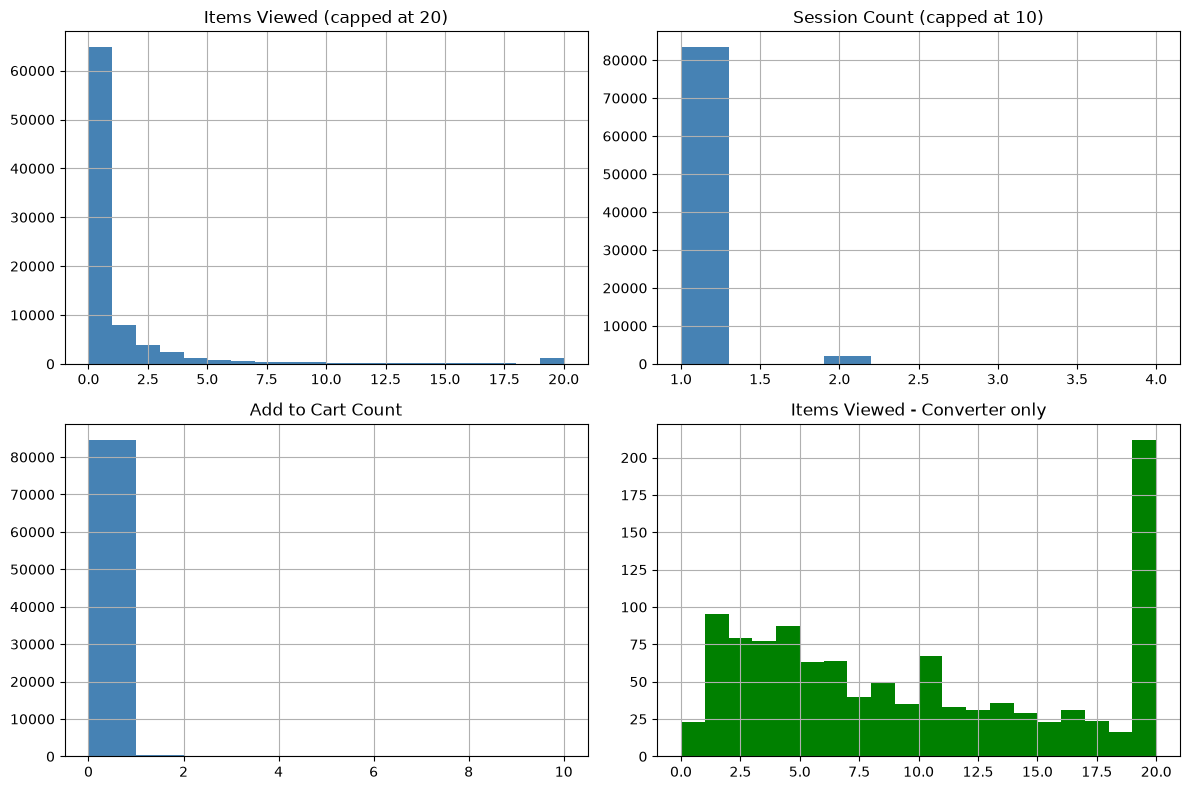

In [18]:
# Verteilung der Kern-Features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['items_viewed'].clip(upper=20).hist(bins=20, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Items Viewed (capped at 20)')

df['session_count'].clip(upper=10).hist(bins=10, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Session Count (capped at 10)')

df['add_to_cart_count'].clip(upper=10).hist(bins=10, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Add to Cart Count')

df[df['converted']==1]['items_viewed'].clip(upper=20).hist(bins=20, ax=axes[1,1], color='green')
axes[1,1].set_title('Items Viewed - Converter only')

plt.tight_layout()
plt.show()

In [19]:
# Checkpoint speichern
df.to_csv('../data/processed/ga4_merch_store_clean.csv', index=False)
print("Gespeichert.")

Gespeichert.
